In [ ]:
# goal indentify a stationary o no stationary time series

In [ ]:
# Iván Andrés Trujillo Abella
# ivantrujillo1229@gmail.com

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
np.arange(7)

array([0, 1, 2, 3, 4, 5, 6])

Text(0.5, 1.0, 'White Noise')

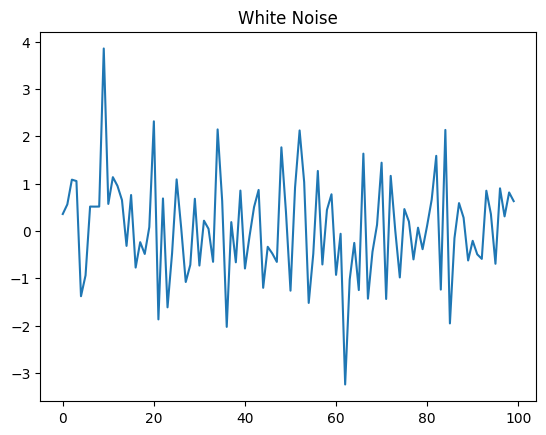

In [ ]:
t = np.arange(100)
y = np.random.normal(0,1, len(t))
plt.plot(t,y)
plt.title("White Noise")

In [ ]:
np.ones_like([97,8,5,9,8,877,9767])

array([1, 1, 1, 1, 1, 1, 1])

In [ ]:
lagged

array([52, 50, 52, 53, 52, 52, 55, 53, 54, 53, 52, 55, 57, 59, 62, 62, 64,
       63, 63, 62, 62, 63, 60, 66, 62, 58, 61, 63, 64, 65, 64, 61, 61, 58,
       60, 59, 56, 55, 56, 54, 51, 51, 51, 49, 47, 47, 42, 37, 34, 33, 33,
       37, 39, 38, 37, 33, 32, 31, 31, 28, 29, 33, 32, 33, 35, 33, 33, 33,
       33, 30, 30, 31, 35, 37, 43, 40, 42, 42, 48, 45, 42, 40, 33, 31, 28,
       28, 29, 34, 36, 34, 31, 32, 28, 33, 36, 34, 28, 32, 31, 34])

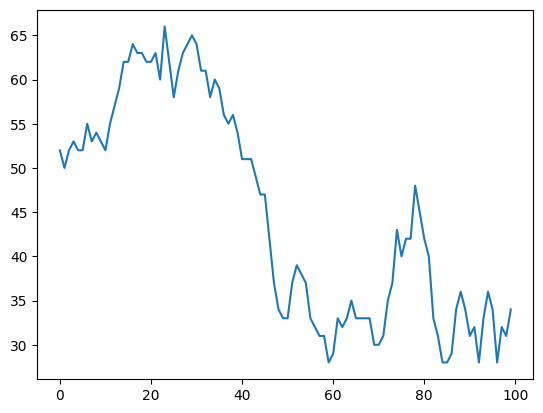

In [ ]:
# Autocorrelated
lagged = np.ones_like(t)
init = 55
for time in t:
  lagged[time] = init + np.random.normal(0,3)
  init  = lagged[time]
plt.plot(t, lagged)

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

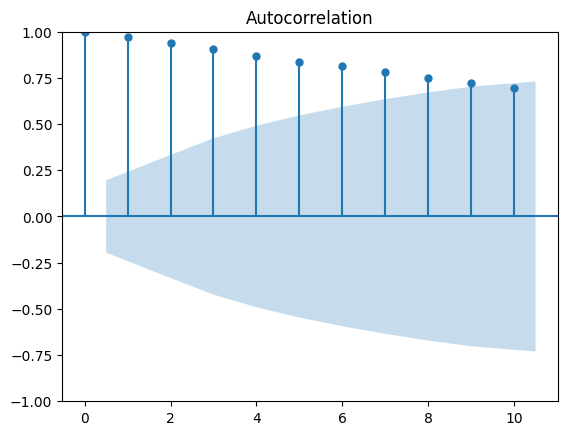

In [ ]:
plot_acf(lagged, lags=10);

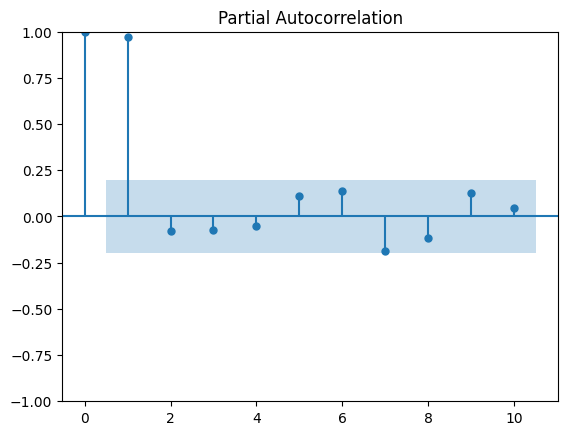

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(lagged, lags=10);  # Plot for the first 20 lags

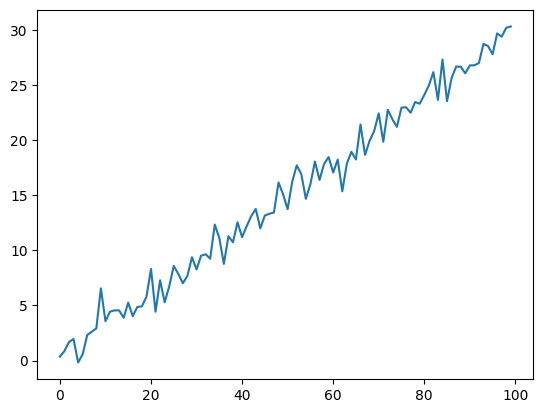

In [ ]:
ytrend = y + ( 0.3 * t)
plt.plot(t, ytrend); #upward trend

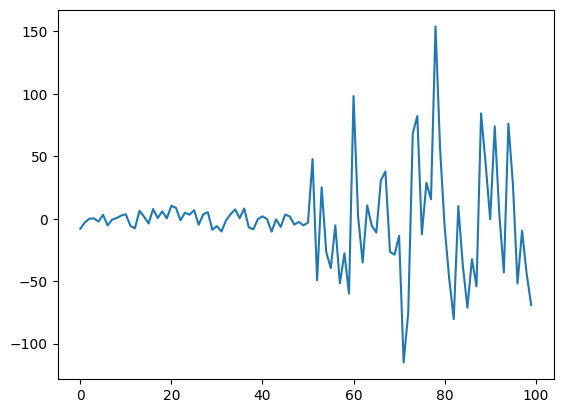

In [ ]:
# Heterecodasticity
y1 = np.random.normal(0,5, len(t)//2)
y2 = np.random.normal(0,50, len(t)//2)
yhet = np.append(y1,y2)
plt.plot(t, yhet)

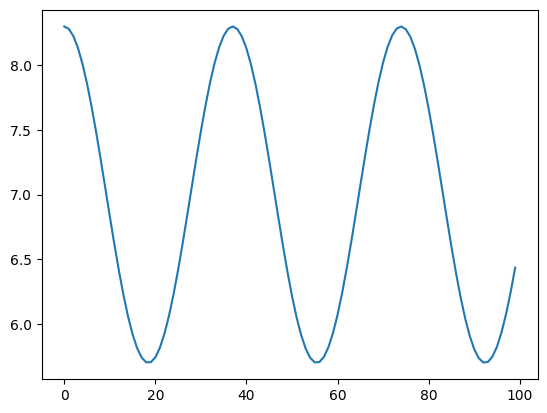

In [ ]:
# we can model seasonality
ysea = 7 +  np.cos(t*0.17) * 1.3
plt.plot(t, ysea)

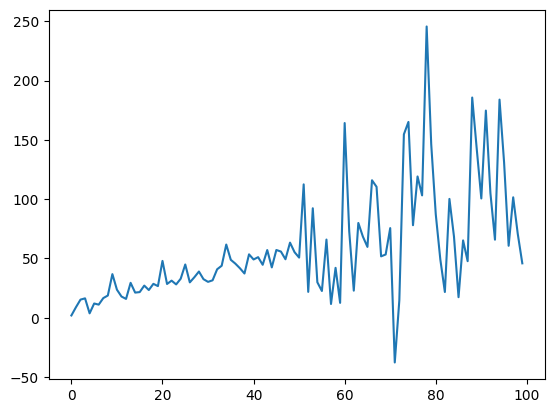

In [ ]:
plt.plot(t, ysea + ytrend*3.56 + y + yhet) # seasonality, trend, heterocedasticy

In [ ]:
# how check stationary
# check constant mean and variance using splits.

In [ ]:
y

array([ 0.35778736,  0.56078453,  1.08305124,  1.05380205, -1.37766937,
       -0.93782504,  0.51503527,  0.51378595,  0.51504769,  3.85273149,
        0.57089051,  1.13556564,  0.95400176,  0.65139125, -0.31526924,
        0.75896922, -0.77282521, -0.23681861, -0.48536355,  0.08187414,
        2.31465857, -1.86726519,  0.68626019, -1.61271587, -0.47193187,
        1.0889506 ,  0.06428002, -1.07774478, -0.71530371,  0.67959775,
       -0.73036663,  0.21645859,  0.04557184, -0.65160035,  2.14394409,
        0.63391902, -2.02514259,  0.18645431, -0.66178646,  0.85243333,
       -0.79252074, -0.11473644,  0.50498728,  0.86575519, -1.20029641,
       -0.33450124, -0.47494531, -0.65332923,  1.76545424,  0.40498171,
       -1.26088395,  0.91786195,  2.1221562 ,  1.03246526, -1.51936997,
       -0.48423407,  1.26691115, -0.70766947,  0.44381943,  0.77463405,
       -0.92693047, -0.05952536, -3.24126734, -1.02438764, -0.25256815,
       -1.24778318,  1.6324113 , -1.43014138, -0.44004449,  0.13

In [ ]:
# white noise
splits = np.split(y, indices_or_sections=10)
for i in splits:
  print(np.mean(i), np.std(i))
print("--"* 20)
# trend
splits = np.split(ytrend, indices_or_sections=10)
for i in splits:
  print(np.mean(i), np.std(i))

0.6136531169136121 1.318174056885202
0.23424159118053267 0.6302551850047212
-0.09112142947145804 1.240193907151637
0.000988515994582817 1.0632902228322074
-0.002915094213836128 0.8444860176052001
0.25856905766066535 1.1304473463157085
-0.6859496125841146 1.1939101926820572
-0.00572659191805232 0.8498128215267109
0.13996193715879943 1.1618688160112935
0.18726104028375307 0.5977747367726615
----------------------------------------
1.963653116913612 1.8147808540929422
4.5842415911805325 0.6266710979322195
7.258878570528542 1.4192187205674194
10.350988515994583 1.402933870579992
13.347084905786161 1.380357081105313
16.608569057660663 1.4484931802714602
18.664050387415887 1.6895289469029806
22.34427340808195 1.040907550408955
25.489961937158803 1.2802951231226956
28.537261040283756 1.306813055248321


In [ ]:
# The same result!
np.mean(splits, axis = 1)

array([ 1.96365312,  4.58424159,  7.25887857, 10.35098852, 13.34708491,
       16.60856906, 18.66405039, 22.34427341, 25.48996194, 28.53726104])

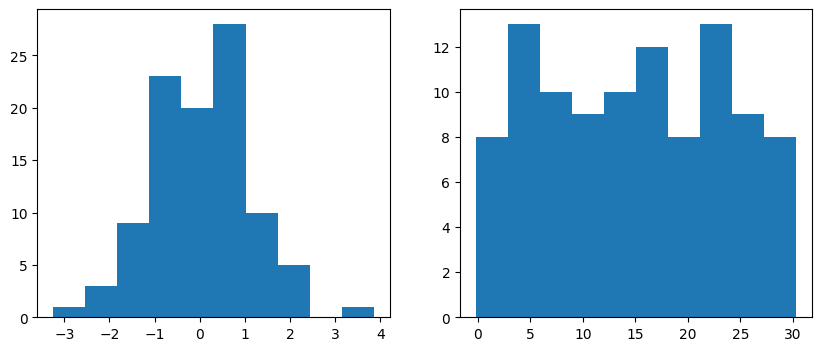

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns
axes[0].hist(y) # White noise
axes[1].hist(ytrend) # trend - uniform!
plt.show()

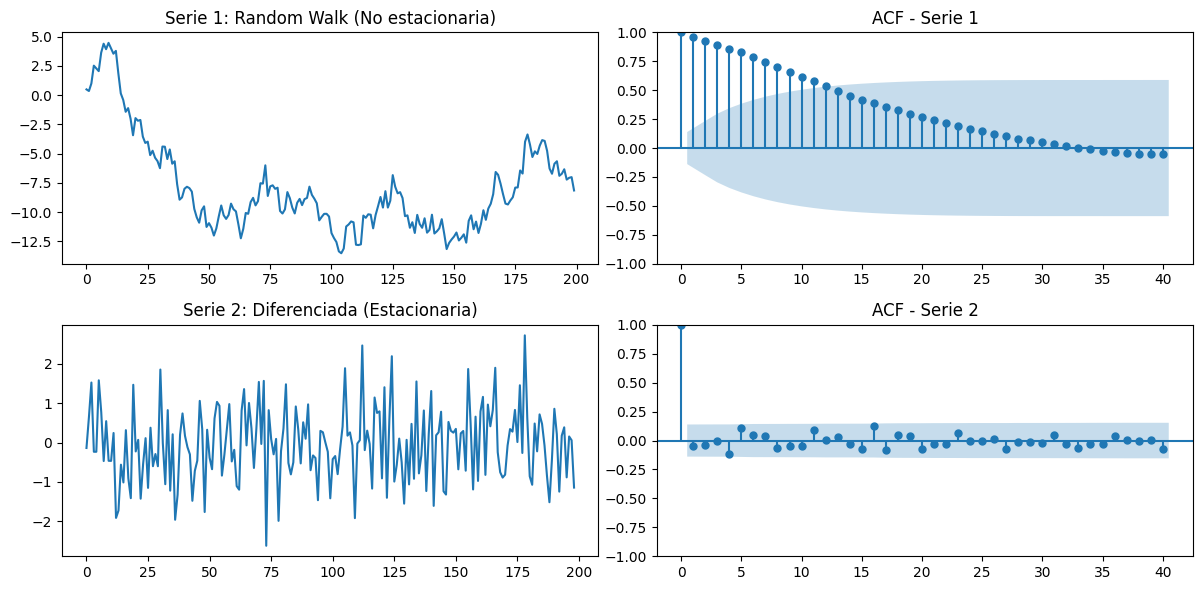

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

np.random.seed(42)

# Serie 1: Random Walk (No estacionaria)
n = 200
epsilon = np.random.normal(0, 1, n)
random_walk = np.cumsum(epsilon)  # suma acumulada => caminata aleatoria

# Serie 2: Diferenciada (estacionaria)
diff_series = np.diff(random_walk)

# Graficar las series
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.plot(random_walk)
plt.title('Serie 1: Random Walk (No estacionaria)')

plt.subplot(2, 2, 2)
plot_acf(random_walk, ax=plt.gca(), lags=40)
plt.title('ACF - Serie 1')

plt.subplot(2, 2, 3)
plt.plot(diff_series)
plt.title('Serie 2: Diferenciada (Estacionaria)')

plt.subplot(2, 2, 4)
plot_acf(diff_series, ax=plt.gca(), lags=40)
plt.title('ACF - Serie 2')

plt.tight_layout()
plt.show()


# Aumented dicked fuller test

tell us if is stationary or not namely unit root.


$$H_{0}: \text{unit root ( no stationary)}$$

if the p - value is lesser than 0.05 then  time serie is stationary

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
adfuller(y)[1] # p value

np.float64(3.8766692506266337e-20)

In [ ]:
adfuller(ytrend)[1] # p-value! # why this serie is no stationary?

np.float64(0.9591189937589912)

In [ ]:
adfuller(yhet)[1] # reject the null hypothesis!! but in really is non-stationary!!!! take care!!!

np.float64(9.658541607128323e-10)

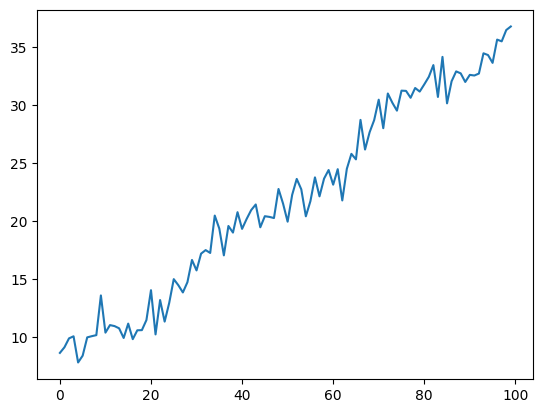

In [ ]:
# Common transformations !!!
ytrendsea = ysea + ytrend
plt.plot(t, ytrendsea)

In [ ]:
adfuller(ytrendsea)[1] # non-stationary!!! there is high propapibility of this
# data come from a generator process governed by H0

np.float64(0.9717707458381961)

# Decompose
we need remove trend and model de seasonal component!

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
import numpy as np
from statsmodels.tsa.stattools import acf
from scipy.signal import find_peaks


lag_acf = acf(ytrendsea, nlags=60)

acf_values = lag_acf[1:]

picos, _ = find_peaks(acf_values, height=0.3)

if len(picos) > 0:
    periodo_acf = picos[0] + 1
    print(f"Período detectado por ACF (pico real): {periodo_acf} observaciones")
else:
    print("No se detectaron picos claros en la ACF")


No se detectaron picos claros en la ACF


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
# Ajustar regresión lineal para la tendencia
model = LinearRegression()
t = t.reshape(-1,1)
model.fit(t, ytrendsea)
tendencia = model.predict(t)
serie_detrended = ytrendsea - tendencia

In [ ]:
fs = 1  # muestras por año
X = np.fft.fft(serie_detrended)
n = len(X)
freq = np.fft.fftfreq(n, d=1/fs)
# Frecuencias positivas
mask = freq > 0
freq_pos = freq[mask]
mag_pos = np.abs(X[mask])

# Frecuencia dominante
idx_max = np.argmax(mag_pos)
freq_dom = freq_pos[idx_max]
periodo_dom = 1/freq_dom
print(f"Periodo dominante: {periodo_dom:.2f} años")

Periodo dominante: 33.33 años


In [ ]:
descomposed = seasonal_decompose(x= ytrendsea, period = int(periodo_dom))

In [ ]:
trend = descomposed.trend
seasonal = descomposed.seasonal
resid = descomposed.resid

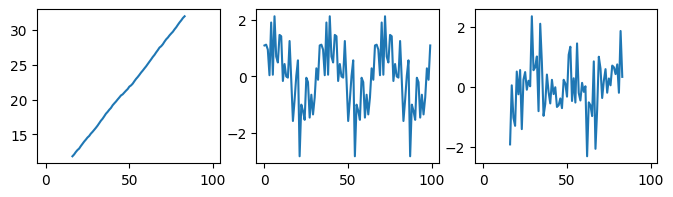

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(8, 2), sharex=True)
axs[0].plot(t, trend)
axs[1].plot(t, seasonal)
axs[2].plot(t, resid)

In [ ]:
resid_ = resid[~np.isnan(resid)]
adfuller(resid_)[1] # stationary

np.float64(0.01347378282514407)

In [ ]:
adfuller(ytrendsea)[1] # The origianl withouth decomposition!

np.float64(0.9717707458381961)

9.658541607128323e-10


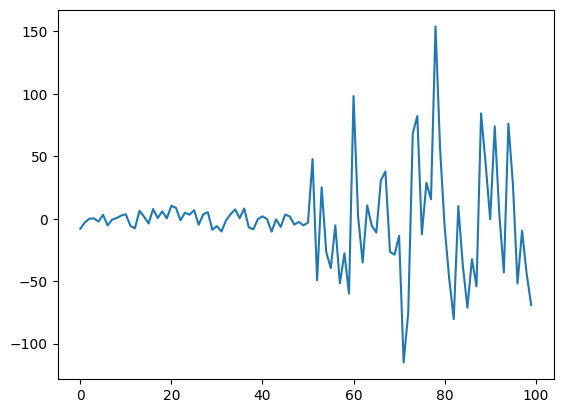

In [ ]:
# Heterocedastic data
plt.plot(t,yhet) # see how grow the variance and the end !! remember that ADF not work properly(inferneces) on heterocedastic series!
print(adfuller(yhet)[1]) # say ath is stationary!
# adfuller capture trend or autocorrelation! unit root remeber what means!

In [ ]:
# make a log transformation!!

In [ ]:
log_yhet = np.log(yhet + abs(yhet.min()) + 0.01)

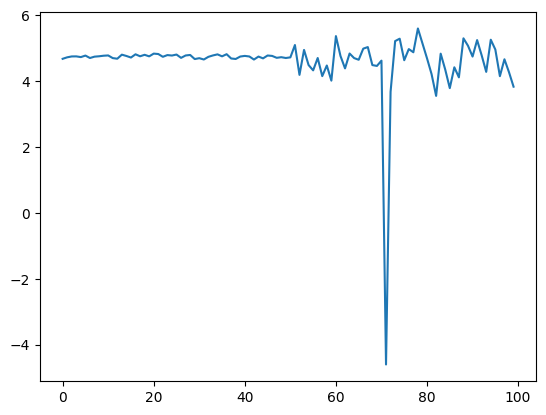

In [ ]:
plt.plot(t, log_yhet)

In [ ]:
adfuller(log_yhet)[1]

np.float64(2.2748560366621738e-14)

removing autocorrelation.

In [ ]:
len(lagged)
adfuller(lagged)[1] # no-stationarity

np.float64(0.7678574849666437)

In [ ]:
differenced  = lagged[:-1] - lagged[1:]

we can remove autocorrelation differencing...
write that fix differeicing...

In [ ]:
adfuller(differenced)[1] #stationary! # differencing one time make it stationary!

np.float64(1.4334522190987e-15)

In [ ]:
adfuller(ytrend)[1]

np.float64(0.9591189937589912)

In [ ]:
adfuller(np.diff(ytrend))[1]

np.float64(5.308548898541005e-12)

Tener autocorrelación en sí misma no es malo — de hecho, en modelado de series de tiempo (ARIMA, GARCH, etc.) la buscamos para poder capturar relaciones entre observaciones pasadas y presentes.

El problema es cuando la autocorrelación es “espuria”, es decir, aparece no porque exista una verdadera dependencia temporal en los datos, sino porque:

Hay una tendencia estocástica (unit root / random walk).

O hay una tendencia determinista (una línea ascendente o descendente que no es estacionaria).

En esos casos:

La ACF puede mostrar valores altos en muchos lags simplemente porque el nivel de la serie se va desplazando lentamente.

Esa “fuerza” no viene de una relación económica, física o causal real, sino del arrastre que provoca la no estacionariedad.

Por eso:

Si no quitamos ese componente (con differencing o detrending), cualquier prueba estadística o modelo puede dar resultados engañosos.

Esto es lo que pasa, por ejemplo, en la regresión espuria: dos random walks sin relación real pueden mostrar una correlación altísima y autocorrelaciones muy persistentes.

💡 En resumen:

Queremos autocorrelación real (de un proceso estacionario).

No queremos autocorrelación espuria (creada por tendencia o unit roots).

Por eso, antes de modelar, probamos estacionariedad (ADF, KPSS, etc.) y, si es necesario, diferenciamos o quitamos tendencia para que la autocorrelación que quede sea la “útil” para el modelo.